In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
import re
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [ ]:
# pip install requests geopandas matplotlib scipy

In [3]:
df_maestro = pd.read_csv('https://media.githubusercontent.com/media/clararodriguezacevedo/descriptiva-real-estate/refs/heads/main/data/raw/dataframe_maestro.tsv', sep='\t')

In [4]:
df_maestro.shape

(66180, 21)

In [5]:
df = df_maestro.copy()

# Análisis Inicial

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  str    
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  str    
 3   Operación          66180 non-null  str    
 4   Precio             66180 non-null  str    
 5   Expensas           45549 non-null  str    
 6   Calle              60722 non-null  str    
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  str    
 9   Barrio             66180 non-null  str    
 10  Detalles           65957 non-null  str    
 11  Descripción        65868 non-null  str    
 12  Link               66180 non-null  str    
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       66180 non-null

In [7]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso',
       'Balcon_Aterrazado'],
      dtype='str')

In [8]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,6.618000e+04,60722.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,3.692180e+07,2255.691726,1.272635,0.097749,0.316893,0.072983,0.288697,0.213796,0.601224,0.091674
std,2.008695e+07,1714.396910,1.714579,0.296977,0.465269,0.260110,0.453160,0.409987,0.489650,0.288568
min,1.527159e+06,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.863395e+07,950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.938779e+07,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5.842992e+07,3100.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,5.882838e+07,54300.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Normalizamos los nombres de las columnas

In [9]:
df = df.rename(columns={"Sito": "sitio","Operación": "operacion"})

In [10]:
df.columns = (df.columns.str.lower())

Revisamos las filas duplicadas y eliminamos los registros idénticos

In [11]:
#verifico si hay duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [12]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [13]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


In [14]:
df.isnull().sum()

fecha_scraping           0
posting_id               0
sitio                    0
operacion                0
precio                   0
expensas             19838
calle                 5370
altura                5370
piso                 49314
barrio                   0
detalles               220
descripción            293
link                     0
amenities                0
losa_central             0
aire_acond               0
apto_credito             0
cochera                  0
seguridad                0
luminoso                 0
balcon_aterrazado        0
dtype: int64

In [15]:
df['piso'].value_counts(dropna=False)

piso
NaN    49314
1       2117
2       1866
3       1416
4       1229
       ...  
41         1
alt        1
9no        1
213        1
pa         1
Name: count, Length: 123, dtype: int64

In [16]:
df['barrio'].value_counts(dropna=False)   

barrio
Palermo                           6433
Recoleta                          5549
Belgrano                          4544
Caballito                         3322
Villa Urquiza                     2374
                                  ... 
Barrio Parque General Belgrano       3
Concepción                           3
Otro                                 3
Los Perales                          1
Barrio Justo Suarez                  1
Name: count, Length: 106, dtype: int64

Arreglamos las columnas de los precios, identificando la moneda utilizada. Asumimos que los precios que leen 'USD' son los que están en dólares, y los que no los que estan en Pesos. 

In [17]:
import re

# Detectamos la moneda a partir del texto del precio, incluyendo variaciones comunes
patron_usd = r'usd|u\$s|u\$d|us\$|dolar(es)?|dollar(s)?'

df['moneda'] = df['precio'].apply(
    lambda x: 'usd' if re.search(patron_usd, str(x).lower()) else 'ars'
)

print("Distribución de monedas detectadas:")
print(df['moneda'].value_counts())

Distribución de monedas detectadas:
moneda
usd    46128
ars    16809
Name: count, dtype: int64


In [18]:
# Limpiamos el texto del precio eliminando todos los indicadores de moneda y símbolos
df['precio'] = (
    df['precio']
    .astype(str)
    .str.lower()
    .str.replace(r'u\$s|u\$d|us\$', '', regex=True)
    .str.replace('usd', '', regex=False)
    .str.replace('ars', '', regex=False)
    .str.replace('dolares', '', regex=False)
    .str.replace('dolar', '', regex=False)
    .str.replace('dollars', '', regex=False)
    .str.replace('dollar', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
df['precio'] = df['precio'].apply(lambda x: float(x) if x != 'consultar' and x != '' else np.nan)

Las expensas están siempre expresadas en pesos

In [19]:
df['expensas'] = (df['expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['expensas'] = df["expensas"].apply(lambda x: float(x) if x != '' else np.nan)

### Análisis de expensas

Las expensas deberían estar expresadas en pesos argentinos. Sin embargo, es posible que algunos valores estén en dólares o sean valores inusualmente bajos que no corresponden a la realidad del mercado de 2026 en Buenos Aires. El siguiente análisis busca detectar valores sospechosos que podrían indicar errores de carga o valores en otra moneda.

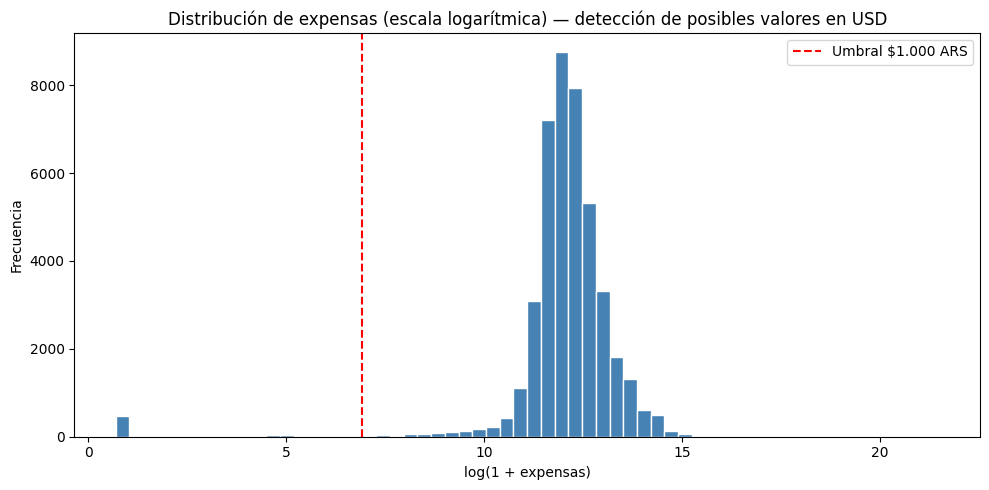

In [20]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df['expensas'].dropna()
ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
ax.axvline(np.log1p(1000), color='red', linestyle='--', label='Umbral $1.000 ARS')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Estadísticas resumen de expensas por tipo de operación
resumen_expensas = df.groupby('operacion')['expensas'].agg(
    count='count',
    media='mean',
    mediana='median',
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95)
).round(0)

print("Resumen de expensas por tipo de operación:")
print(resumen_expensas)

# Valores sospechosamente bajos: menos de 1000 ARS en 2026 es prácticamente imposible
# TODO: por que este valor arbitrario de 1000 ARS? podria ser mas alto, no se puede hacer algun analisis para ver donde seria el cutoff point?
umbral_sospechoso = 1000
sospechosos = df[df['expensas'] < umbral_sospechoso]['expensas'].dropna()
print(f"\nExpensas con valor menor a ${umbral_sospechoso} ARS (posibles errores o valores en USD): {len(sospechosos)}")
if len(sospechosos) > 0:
    print("Ejemplos:")
    print(df[df['expensas'] < umbral_sospechoso][['operacion', 'precio', 'moneda', 'expensas']].head(10))

Resumen de expensas por tipo de operación:
                   count     media   mediana       p5       p95
operacion                                                      
alquiler           17977  523271.0  180000.0  74000.0  750000.0
alquiler_temporal   3009  202799.0  150000.0    540.0  500000.0
venta              22113  298931.0  187200.0  40000.0  900000.0

Expensas con valor menor a $1000 ARS (posibles errores o valores en USD): 621
Ejemplos:
     operacion     precio moneda  expensas
356   alquiler     2800.0    usd     250.0
386   alquiler     1500.0    usd       1.0
527   alquiler     3700.0    usd       1.0
585   alquiler     4100.0    usd       1.0
646   alquiler     4600.0    usd      10.0
745   alquiler     2200.0    usd       1.0
796   alquiler     1000.0    usd     380.0
804   alquiler   600000.0    ars       1.0
953   alquiler  1000000.0    ars       1.0
1034  alquiler  1000000.0    ars       1.0


In [22]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14458  8.282753e+05  700000.0  9.965850e+05   
       alquiler_temporal    810  7.122810e+05  750000.0  3.849273e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6879  5.346962e+03    1200.0  5.369935e+04   
       alquiler_temporal   6065  5.744404e+03     850.0  2.247339e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler               1.0  111111111.0  
       alquiler_temporal      1.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      5.0   12322222.0  
       venta                  1.0   12000000.0

### Observación sobre valores mínimos y máximos ficticios

Se puede observar que prácticamente todos los segmentos (moneda × operación) presentan un mínimo de **1** o valores extremadamente bajos. Estos no son precios reales: corresponden a publicaciones donde el vendedor o intermediario no quiso revelar el precio y utilizó un valor simbólico (como "1 peso") como marcador de posición (*placeholder*).

De manera análoga, los valores máximos extremos como **111.111.111 ARS** o **12.322.222 USD** pueden ser artificiales. Es una práctica habitual en portales inmobiliarios ingresar valores como "111111111" o "999999999" para indicar que el precio está a consultar, en lugar de dejar el campo vacío.

Estos valores ficticios distorsionan cualquier análisis estadístico (medias, desvíos, visualizaciones), entonces es necesario removerlos con un proceso de detección de outliers.

### Visualización de precios por segmento

Graficar todos los segmentos en un mismo eje sería engañoso: los precios en ARS y en USD difieren en órdenes de magnitud, y los alquileres y ventas tampoco son comparables entre sí. Por eso utilizamos subplots independientes con escala libre en cada eje, de modo que cada combinación (moneda × operación) sea legible por separado.

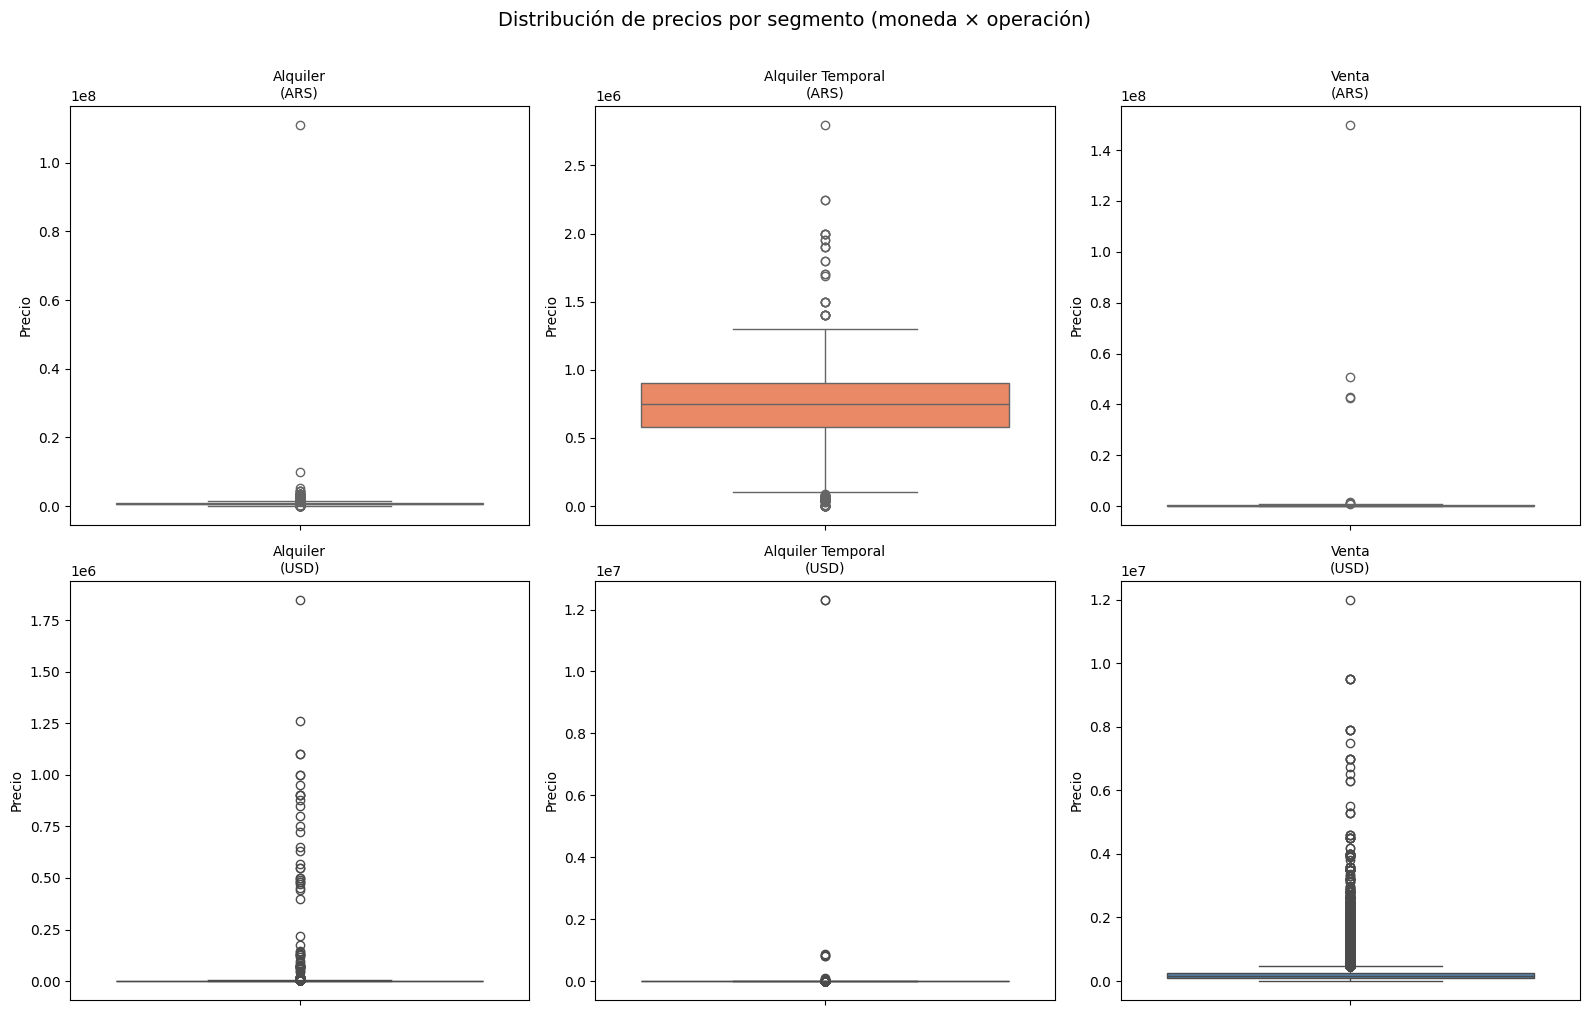

In [23]:
df_plot = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Definimos los segmentos a graficar
monedas = ['ars', 'usd']
operaciones = ['alquiler', 'alquiler_temporal', 'venta']

fig, axes = plt.subplots(
    nrows=len(monedas),
    ncols=len(operaciones),
    figsize=(16, 10),
    sharex=False,
    sharey=False
)

for i, moneda in enumerate(monedas):
    for j, operacion in enumerate(operaciones):
        ax = axes[i][j]
        subset = df_plot[(df_plot['moneda'] == moneda) & (df_plot['operacion'] == operacion)]['precio'].dropna()

        if len(subset) > 0:
            sns.boxplot(y=subset, ax=ax, color='steelblue' if moneda == 'usd' else 'coral')
            ax.set_title(f"{operacion.replace('_', ' ').title()}\n({moneda.upper()})", fontsize=10)
        else:
            ax.set_visible(False)

        ax.set_xlabel("")
        ax.set_ylabel("Precio")

fig.suptitle("Distribución de precios por segmento (moneda × operación)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

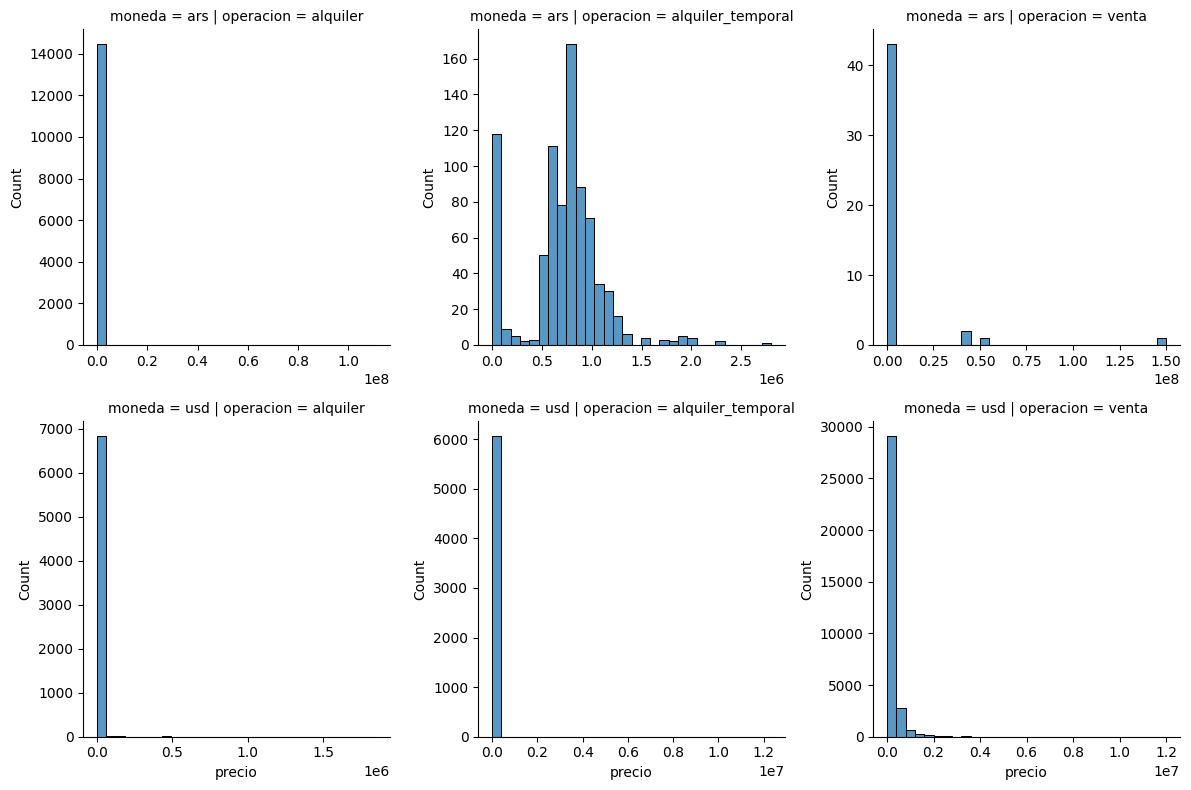

In [24]:
df_precio = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# TODO: ajustar escalas, no tiene sentido 1e8
g = sns.FacetGrid(df_precio, row="moneda", col="operacion", sharex=False, sharey=False, height=4)
g.map(sns.histplot, "precio", bins=30)
plt.show()

# TODO: agregar comentario que diga que, aunque SI estan en escalas distintas los graficos (algunous en 1e8, otros en 1e6), igual los outliers distorsionan la visualizacion y eso hace que no se puedan ver bien la distribucion. entonces se procede a eliminar los outliers despues

Para poder graficar un mapa con las propiedades por barrio, primero debemos normalizar los títulos de los barrios

In [25]:
mapeo = {
    "Palermo Nuevo": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Las Cañitas": "Palermo",
    "Botanico": "Palermo",
    "Botánico": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Barrio Chino": "Belgrano",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",
    "Abasto": "Almagro",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Primera Junta": "Caballito",
    "Cid Campeador": "Caballito",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",

    "Centro": "San Nicolas",
    "Microcentro": "San Nicolas",
    "Centro / Microcentro": "San Nicolas",
    "San Nicolás": "San Nicolas",
    "Tribunales": "San Nicolas",
    "Congreso": "San Nicolas",

    "Núñez": "Nuñez",
    "Lomas De Núñez": "Nuñez",
    "Lomas De Nuñez": "Nuñez",
    "River": "Nuñez",

    "Constitución": "Constitucion",
    "Concepción": "San Cristobal",
    "Once": "Balvanera",
    "Pompeya": "Nueva Pompeya",

    "Barrio Norte": "Recoleta",
    "Plaza San Martín": "Retiro",
    "Catalinas": "Retiro",
    "Puerto Retiro": "Retiro",

    "Parque Centenario": "Caballito",
    "Parque Las Heras": "Palermo",

    "Urquiza R": "Villa Urquiza",

    "Villa Pueyrredón": "Villa Pueyrredon",
    "Villa General Mitre": 'Villa Gral. Mitre',
    "La Paternal": "La Paternal",
    "Los Perales": "Mataderos",
    "Agronomía": "Agronomia",

    "Boca": "La Boca",

    "Barrio Norte": "Recoleta",
    "Barrio Parque Saavedra": "Saavedra",
    "Barrio Parque General Belgrano": "Belgrano",
    "Barrio San Pedro": "Saavedra",
    "Barrio Justo Suarez": "Villa Urquiza",
    "Barrio Naón": "Agronomia",
    "Naón": "Agronomia",
    "Barrio Parque": "Palermo",
    "Distrito Quartier": "Puerto Madero",

    "Otro": None, 
}

In [ ]:
import requests
import geopandas as gpd

# Descargamos el GeoJSON oficial de barrios de la Ciudad de Buenos Aires desde datos abiertos
url_geojson = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
geojson_barrios = requests.get(url_geojson).json()

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}

df["barrio_norm"] = df["barrio"].str.strip().str.title()
df["barrio_oficial"] = df["barrio_norm"].replace(mapeo)

df_filtrado = df[df["barrio_oficial"].isin(nombres_geojson)]
conteo = df_filtrado.groupby("barrio_oficial").size().reset_index(name="cantidad")

nombres_df = set(conteo["barrio_oficial"])
print("Barrios sin coincidencia en el GeoJSON:", nombres_df - nombres_geojson)


In [ ]:
# Construimos el GeoDataFrame de barrios y lo mergeamos con el conteo de propiedades
gdf = gpd.GeoDataFrame.from_features(geojson_barrios["features"])
gdf = gdf.rename(columns={"nombre": "barrio_oficial"})
gdf = gdf.set_crs("EPSG:4326")

gdf_conteo = gdf.merge(conteo, on="barrio_oficial", how="left")

# --- Mapa: cantidad de propiedades por barrio ---
fig, ax = plt.subplots(figsize=(12, 10))

gdf_conteo.plot(
    column="cantidad",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Cantidad de propiedades", "shrink": 0.7},
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
    ax=ax,
)

# Anotamos los top-8 barrios por cantidad
top_barrios = gdf_conteo.nlargest(8, "cantidad")
for _, row in top_barrios.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["barrio_oficial"],
        xy=(centroide.x, centroide.y),
        ha="center",
        fontsize=6.5,
        color="black",
        fontweight="bold",
    )

ax.set_title("Cantidad de propiedades publicadas por barrio (CABA)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


Como se puede ver en el mapa, los barrios de Palermo, Belgrano, Recoleta y Caballito son los más representados en las bases de datos.

## Análisis geoespacial de precios por barrio

A continuación se presentan mapas coropléticos del precio mediano por barrio, separados por tipo de operación y moneda. Usamos la columna `precio` (ya limpia de texto) del DataFrame principal. Para venta e inmuebles con precio disponible se calcula también el precio mediano por m².

In [ ]:
def graficar_mapa_precio(gdf_base, df_source, filtro_operacion, filtro_moneda,
                          columna_precio, titulo, etiqueta_leyenda,
                          cmap="Blues", top_n=8, fmt_precio="{:,.0f}"):
    """
    Genera un mapa coroplético de precio mediano por barrio usando geopandas + matplotlib.

    Parámetros
    ----------
    gdf_base           : GeoDataFrame con la geometría de los barrios (columna 'barrio_oficial')
    df_source          : DataFrame con columnas barrio_oficial, operacion, moneda y columna_precio
    filtro_operacion   : str, valor de la columna 'operacion' a filtrar
    filtro_moneda      : str, valor de la columna 'moneda' a filtrar
    columna_precio     : str, columna numérica a agregar con la mediana
    titulo             : str, título del mapa
    etiqueta_leyenda   : str, etiqueta de la barra de colores
    cmap               : str, colormap de matplotlib
    top_n              : int, cantidad de barrios a anotar
    fmt_precio         : str, formato para el texto de anotación
    """
    # Filtrado y cálculo de mediana por barrio
    mask = (
        (df_source["operacion"] == filtro_operacion)
        & (df_source["moneda"] == filtro_moneda)
        & df_source[columna_precio].notna()
        & (df_source[columna_precio] > 0)
        & df_source["barrio_oficial"].notna()
    )
    estadisticas = (
        df_source[mask]
        .groupby("barrio_oficial")[columna_precio]
        .median()
        .reset_index()
        .rename(columns={columna_precio: "precio_mediano"})
    )

    gdf_merge = gdf_base.merge(estadisticas, on="barrio_oficial", how="left")

    fig, ax = plt.subplots(figsize=(12, 10))

    gdf_merge.plot(
        column="precio_mediano",
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=True,
        legend_kwds={"label": etiqueta_leyenda, "shrink": 0.7},
        missing_kwds={"color": "lightgray", "label": "Sin datos"},
        ax=ax,
    )

    # Anotamos los top-N barrios con mayor precio mediano
    top = gdf_merge.dropna(subset=["precio_mediano"]).nlargest(top_n, "precio_mediano")
    for _, row in top.iterrows():
        centroide = row.geometry.centroid
        ax.annotate(
            row["barrio_oficial"],
            xy=(centroide.x, centroide.y),
            ha="center",
            fontsize=6,
            color="black",
            fontweight="bold",
        )

    ax.set_title(titulo, fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [ ]:
# df_geo: registros con barrio_oficial válido para análisis geoespacial
# Nota: m2_total y precio_por_m2 solo estarán disponibles si la sección de
# parseo de detalles/descripción ya fue ejecutada previamente.
df_geo = df_filtrado.copy()

if "m2_total" in df.columns:
    df_geo["m2_total"] = df.loc[df_geo.index, "m2_total"]
    mask_m2 = df_geo["m2_total"].notna() & (df_geo["m2_total"] > 5) & df_geo["precio"].notna() & (df_geo["precio"] > 0)
    df_geo.loc[mask_m2, "precio_por_m2"] = df_geo.loc[mask_m2, "precio"] / df_geo.loc[mask_m2, "m2_total"]
    print(f"Registros con precio_por_m2 calculado: {mask_m2.sum():,}")
else:
    print("m2_total aún no disponible (ejecutar sección de parseo de detalles primero).")

print(f"Registros en df_geo: {len(df_geo):,}")
print(df_geo[["operacion", "moneda"]].value_counts())


### Precio mediano de venta (USD) por barrio

In [ ]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="venta",
    filtro_moneda="usd",
    columna_precio="precio",
    titulo="Precio mediano de venta en USD por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (USD)",
    cmap="OrRd",
    top_n=8,
)


### Precio mediano de alquiler (ARS) por barrio

In [ ]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="alquiler",
    filtro_moneda="ars",
    columna_precio="precio",
    titulo="Precio mediano de alquiler en ARS por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (ARS)",
    cmap="YlGn",
    top_n=8,
)


### Precio mediano por m² en venta (USD) por barrio

Este mapa muestra el precio mediano por metro cuadrado para propiedades en venta con precio en dólares. La columna `m2_total` proviene del parseo de la columna `detalles` (superficie total o cubierta). Solo se incluyen propiedades con `m2_total > 5 m²`.

In [ ]:
if "precio_por_m2" in df_geo.columns:
    graficar_mapa_precio(
        gdf_base=gdf,
        df_source=df_geo,
        filtro_operacion="venta",
        filtro_moneda="usd",
        columna_precio="precio_por_m2",
        titulo="Precio mediano por m² en venta USD por barrio (CABA)",
        etiqueta_leyenda="Precio mediano por m² (USD/m²)",
        cmap="RdPu",
        top_n=8,
    )
else:
    print("No se pudo generar el mapa: la columna 'precio_por_m2' no está disponible.")
    print("Asegurate de ejecutar la celda de parseo de 'detalles' antes de esta.")


In [30]:
tabla_barrio_operacion = (
    df.groupby(["barrio_oficial", "operacion"])
      .size()
      .unstack(fill_value=0)
)

tabla_barrio_operacion["Total_barrio"] = tabla_barrio_operacion.sum(axis=1)
tabla_barrio_operacion.loc["Total_operacion"] = tabla_barrio_operacion.sum(axis=0)

tabla_barrio_operacion

operacion,alquiler,alquiler_temporal,venta,Total_barrio
barrio_oficial,,,,
Agronomia,30,1,92,123
Almagro,805,412,1446,2663
Balvanera,621,195,1156,1972
Barracas,220,15,488,723
Belgrano,1812,604,3322,5738
Boedo,175,15,352,542
Caballito,1500,239,2567,4306
Chacarita,122,41,203,366
Coghlan,96,26,311,433


La cantidad mínima de propiedades de los barrios se encuentra en Villa Riachuelo, con 5 propiedades. Asimismo, la operación con la menor cantidad de propiedades disponibles es 'alquiler_temporal'. Por ende, esperamos que las conclusiones más robustas del análisis sean sobre los barrios con mayor cantidad de propiedades (como los mencionados previamente), pero esperamos obtener conclusiones fuertes sobre los tres tipos de operaciones ya que 'alquiler_temporal' siendo la columna con la menor cantidad de filas presenta más de 8000 de las mismas.

# Reconocimiento de outliers

## Corrección de Moneda por Análisis de Valores

Existe una dependencia circular entre la detección de moneda y el análisis de outliers: si un precio en USD fue clasificado como ARS por error, aparecerá como un valor extremadamente bajo dentro del segmento ARS y podría ser tratado como outlier cuando en realidad no lo es.

Para romper este ciclo, realizamos una corrección de moneda **antes** del análisis de outliers: identificamos precios etiquetados como ARS que son estadísticamente imposibles en el mercado argentino de 2026 y los reclasificamos como USD.

### Paso 1 — Diagnóstico visual: distribución de precios ARS por operación

Graficamos los precios clasificados como ARS para alquiler y venta por separado. Si existen valores extremadamente bajos (por ejemplo, alquileres de menos de 5.000 ARS), es muy probable que sean precios en USD que el parser de texto no detectó.

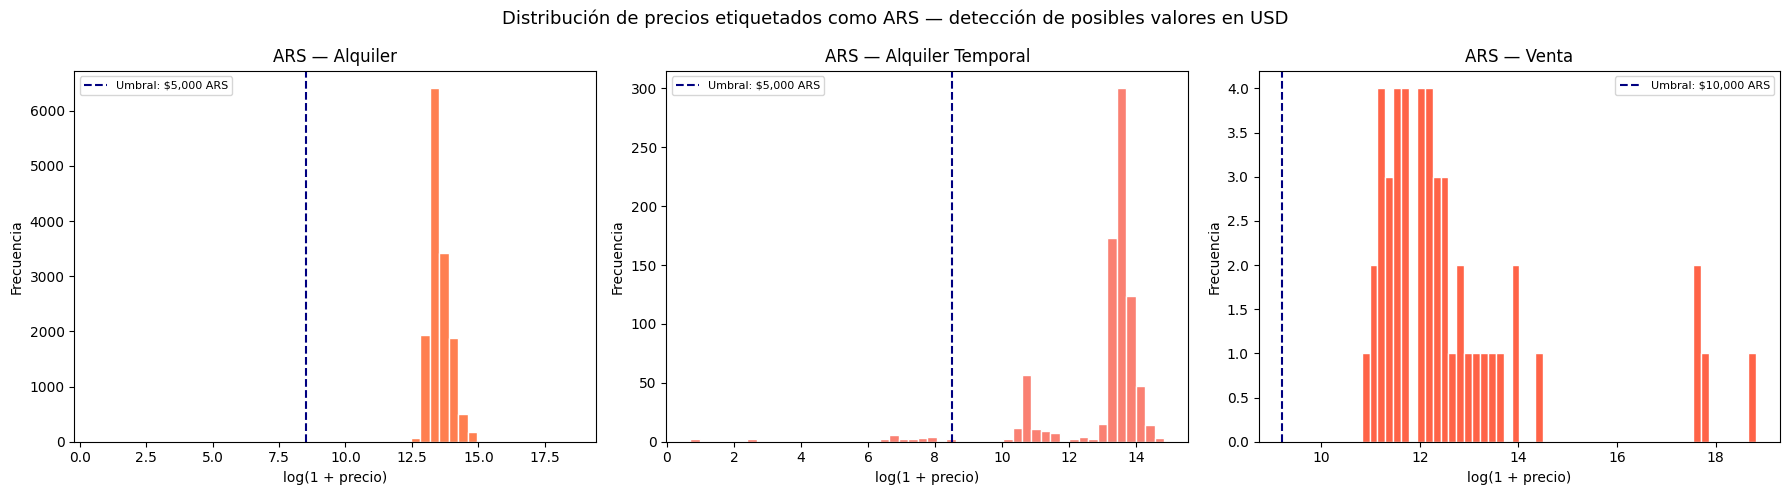

Precios ARS en 'alquiler' menores a $5,000: 28 registros
Precios ARS en 'alquiler_temporal' menores a $5,000: 26 registros
Precios ARS en 'venta' menores a $10,000: 0 registros


In [ ]:
# Diagnóstico visual: precios ARS por operación
# TODO: los umbrales no deberian ser arbitrarios, deberia ser un analisis estadistico para encontrar el cutoff point
# quizas una regresion para ver si tiene sentido ese precio de los inmuebles en esa moneda
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ops = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 5000, 'alquiler_temporal': 5000, 'venta': 10000}
colores = ['coral', 'salmon', 'tomato']

for ax, op, color in zip(axes, ops, colores):
    subset = df[(df['moneda'] == 'ars') & (df['operacion'] == op)]['precio'].dropna()
    ax.hist(np.log1p(subset), bins=50, color=color, edgecolor='white')
    umbral = umbrales[op]
    ax.axvline(np.log1p(umbral), color='navy', linestyle='--', label=f'Umbral: ${umbral:,} ARS')
    ax.set_title(f"ARS — {op.replace('_', ' ').title()}")
    ax.set_xlabel("log(1 + precio)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

fig.suptitle("Distribución de precios etiquetados como ARS — detección de posibles valores en USD", fontsize=13)
plt.tight_layout()
plt.show()

# Cuántos valores están por debajo de los umbrales
for op, umbral in umbrales.items():
    n = ((df['moneda'] == 'ars') & (df['operacion'] == op) & (df['precio'] < umbral)).sum()
    print(f"Precios ARS en '{op}' menores a ${umbral:,}: {n} registros")

### Paso 2 — Reclasificación heurística

Los precios en ARS menores a los umbrales definidos son estadísticamente imposibles en el mercado argentino de 2026 y probablemente corresponden a valores en USD que no fueron detectados por el parser de texto. Los reclasificamos como USD.

In [32]:
# Reclasificación de moneda basada en umbrales de precio
# Un alquiler ARS < 5.000 pesos en 2026 es imposible -> es USD
# Una venta ARS < 10.000 pesos en 2026 es imposible -> es USD

condiciones_reclasificacion = [
    (df['operacion'] == 'alquiler',           5_000),
    (df['operacion'] == 'alquiler_temporal',  5_000),
    (df['operacion'] == 'venta',             10_000),
]

total_reclasificados = 0
for mascara_op, umbral in condiciones_reclasificacion:
    mascara = mascara_op & (df['moneda'] == 'ars') & (df['precio'] < umbral)
    n = mascara.sum()
    total_reclasificados += n
    df.loc[mascara, 'moneda'] = 'usd'
    operacion_nombre = df.loc[mascara_op, 'operacion'].iloc[0] if mascara_op.any() else '?'
    print(f"Reclasificados en '{operacion_nombre}' (precio ARS < {umbral:,}): {n} registros")

print(f"\nTotal de registros reclasificados de ARS a USD: {total_reclasificados}")

Reclasificados en 'alquiler' (precio ARS < 5,000): 28 registros
Reclasificados en 'alquiler_temporal' (precio ARS < 5,000): 26 registros
Reclasificados en 'venta' (precio ARS < 10,000): 0 registros

Total de registros reclasificados de ARS a USD: 54


### Paso 3 — Resumen post-corrección

Comparamos la distribución de monedas antes y después de la reclasificación.

In [33]:
# Resumen de moneda por operación luego de la reclasificación
resumen_moneda_corregido = df.groupby(["moneda", "operacion"])["precio"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
print("Resumen de precios por moneda y operación (post-corrección):")
resumen_moneda_corregido

Resumen de precios por moneda y operación (post-corrección):


count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14430  8.298803e+05  700000.0  9.968844e+05   
       alquiler_temporal    784  7.358542e+05  750000.0  3.684490e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6907  5.329785e+03    1200.0  5.359108e+04   
       alquiler_temporal   6091  5.726098e+03     850.0  2.242539e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler            7000.0  111111111.0  
       alquiler_temporal   5500.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      1.0   12322222.0  
       venta                  1.0   12000000.0

In [34]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda 

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14430  8.298803e+05  700000.0  9.968844e+05   
       alquiler_temporal    784  7.358542e+05  750000.0  3.684490e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6907  5.329785e+03    1200.0  5.359108e+04   
       alquiler_temporal   6091  5.726098e+03     850.0  2.242539e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler            7000.0  111111111.0  
       alquiler_temporal   5500.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      1.0   12322222.0  
       venta                  1.0   12000000.0

Las escalas para los tipos de monedas y tipos de operaciones son diferentes. Por eso, para analizar a los outliers, vamos a separar la base en los distintos casos. También vamos a analizar los outliers según el tipo de moneda ya que los mercados en pesos Argentinos y en Dólares son distintos. 

In [35]:
df_venta_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "venta")].copy() #Ignoramos las ventas en pesos porque son muy pocos registros (47)
df_alquiler_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "alquiler")].copy()
df_alquiler_ars = df[(df["moneda"] == "ars") & (df["operacion"] == "alquiler")].copy()
df_alquilertemp_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "alquiler_temporal")].copy()
df_alquilertemp_ars = df[(df["moneda"] == "ars") & (df["operacion"] == "alquiler_temporal")].copy()


Utilizamos jarque berra para analizar normalidad

In [36]:
from scipy.stats import jarque_bera

dfs = {
    "df_venta_usd": df_venta_usd,
    "df_alquiler_usd": df_alquiler_usd,
    "df_alquiler_ars": df_alquiler_ars,
    "df_alquilertemp_usd": df_alquilertemp_usd,
    "df_alquilertemp_ars": df_alquilertemp_ars
}

for nombre, df_temp in dfs.items():
    serie = df_temp["precio"].dropna()

    print(f"\n--- {nombre} ---")
    print(f"n = {len(serie)}")

    if len(serie) < 3:
        print("No hay suficientes datos para aplicar Jarque-Bera.")
        continue

    stat, p = jarque_bera(serie)

    print(f"Estadístico Jarque-Bera: {stat:.4f}")
    print(f"p-valor: {p:.4f}")

ModuleNotFoundError: No module named 'scipy'

Como el p valor es pequeño, rechazamos normalidad. Verificamos que ninguna columna de precio tenga valores menores a 0 antes de aplicar Box-Cox.

In [ ]:
for nombre, df_temp in dfs.items():
    print(f"{nombre}: {(df_temp['precio'] <= 0).sum()}")

Aplicamos Box Cox y luego utilizamos Tukey para detectar los outliers

In [ ]:
from scipy.stats import boxcox

def tukey_outliers(series):
    serie_valida = series.dropna()
    q1 = np.percentile(serie_valida, 25)
    q3 = np.percentile(serie_valida, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

lambdas = {}
        
for nombre, df_temp in dfs.items():
    print(f"\n{nombre}")
    
    mask_validos = df_temp["precio"].notna() & (df_temp["precio"] > 0)
    
    if mask_validos.sum() < 2:
        print("No hay suficientes valores válidos")
        continue
      
    data_bc, lambda_bc = boxcox(df_temp.loc[mask_validos, "precio"])
    lambdas[nombre] = lambda_bc
    df_temp["boxcox"] = np.nan
    df_temp.loc[mask_validos, "boxcox"] = data_bc
    
    df_temp["outlier_boxcox"] = tukey_outliers(df_temp["boxcox"])
    
    n_outliers = df_temp["outlier_boxcox"].sum()
    print(f"Outliers: {n_outliers}")
    print(f"Porcentaje: {n_outliers / mask_validos.sum() * 100:.2f}%")  # sobre válidos, no total



Como podemos ver, en general hay un porcentaje bajo de outliers a través de cada combinación operación-moneda. Por ende, vamos a realizar imputación mediante Winsor (reemplazar mediante el límite superior o inferior) para mantener la distribución de los datos. 

De todas formas, no vamos a aplicarle este procedimiento a los alquileres temporarios en ARS, ya que este presenta una cantidad más alta de outliers (18%)

In [ ]:
dfs2 = {
    "df_venta_usd": df_venta_usd,
    "df_alquiler_usd": df_alquiler_usd,
    "df_alquiler_ars": df_alquiler_ars,
    "df_alquilertemp_usd": df_alquilertemp_usd
}

from scipy.special import inv_boxcox

for nombre, df_temp in dfs2.items():
    mask_validos = df_temp["boxcox"].notna()
    serie_bc = df_temp.loc[mask_validos, "boxcox"]
    
    q1 = np.percentile(serie_bc, 25)
    q3 = np.percentile(serie_bc, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # Copiamos precio original
    df_temp["precio_imputado"] = df_temp["precio"].copy()
    
    # Solo tocamos las filas donde outlier_boxcox == True
    mask_outlier = df_temp["outlier_boxcox"] == True
    
    boxcox_clippeado = df_temp.loc[mask_outlier, "boxcox"].clip(lower=lim_inf, upper=lim_sup)
    df_temp.loc[mask_outlier, "precio_imputado"] = inv_boxcox(boxcox_clippeado, lambdas[nombre])
    
    print(f"{nombre}: {mask_outlier.sum()} outliers imputados")
    print(f"  precio original (outliers):   {df_temp.loc[mask_outlier, 'precio'].values[:5]}")
    print(f"  precio imputado (outliers):   {df_temp.loc[mask_outlier, 'precio_imputado'].values[:5]}\n")

In [ ]:
# Paso 1: eliminamos directamente los outliers de alquiler_temporal ARS
# (18% de outliers → Winsorizar distorsionaría la distribución)
n_antes = len(df_alquilertemp_ars)
df_alquilertemp_ars = df_alquilertemp_ars[df_alquilertemp_ars['outlier_boxcox'] == False].copy()
n_despues = len(df_alquilertemp_ars)
print(f"alquiler_temporal ARS — eliminados: {n_antes - n_despues} outliers ({(n_antes - n_despues)/n_antes*100:.1f}%)")
print(f"Registros restantes: {n_despues}")

df_alquilertemp_ars['precio_imputado'] = df_alquilertemp_ars['precio'].copy()

# Paso 2: concatenamos todos los segmentos con sus precios tratados
df_precios_limpios = pd.concat([
    df_venta_usd,
    df_alquiler_usd,
    df_alquiler_ars,
    df_alquilertemp_usd,
    df_alquilertemp_ars
], ignore_index=False)

print(f"\nTotal registros en df_precios_limpios: {len(df_precios_limpios):,}")
print(f"Registros originales en df: {len(df):,}")
print(f"Diferencia (ventas ARS + descartados): {len(df) - len(df_precios_limpios):,}")

# Paso 3: mapeamos precio_imputado al DataFrame principal via posting_id
precio_imputado_map = df_precios_limpios.set_index('posting_id')['precio_imputado']
df['precio_final'] = df['posting_id'].map(precio_imputado_map)
df['precio_final'] = df['precio_final'].combine_first(df['precio'])

print(f"\nFilas con precio_final no nulo: {df['precio_final'].notna().sum():,}")

# Paso 4: comparación estadística antes/después
comparacion = df.groupby(['moneda', 'operacion']).agg(
    n_original=('precio', 'count'),
    n_final=('precio_final', 'count'),
    mediana_original=('precio', 'median'),
    mediana_final=('precio_final', 'median'),
).round(0)
print("\nComparación antes/después de limpieza de outliers:")
print(comparacion)

...

# 4. Feature Engineering — Parseo de texto y KPIs

Extraemos variables estructuradas a partir de las columnas de texto libre `detalles` y `descripción` mediante expresiones regulares. Luego materializamos los KPIs definidos en la entrega anterior.

In [ ]:
detalles = df['detalles'].unique()
print(detalles)

## Funciones

In [ ]:
import pandas as pd
import re

def parse_detalles(s):
    """Parsea la columna 'detalles' de ZonaProp/ArgEnProp en columnas individuales."""
    if pd.isna(s):
        return {}
    result = {}

    # Superficie total (ej: "60 m² tot." o "60 m² cubie.")
    m_tot = re.search(r'([\d,\.]+)\s*m²\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²\s*cubie\.?', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # Ambientes (ej: "3 amb." o "3 ambientes")
    amb = re.search(r'(\d+)\s*amb\.', s)
    ambientes = re.search(r'(\d+)\s*ambientes', s)
    if amb:
        result['ambientes'] = int(amb.group(1))
    elif ambientes:
        result['ambientes'] = int(ambientes.group(1))

    # Dormitorios (ej: "2 dorm.")
    dorm = re.search(r'(\d+)\s*dorm\.', s)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # Baños (ej: "1 baño" o "2 baños")
    ban = re.search(r'(\d+)\s*baños?', s)
    if ban:
        result['baños'] = int(ban.group(1))
        
    # Antigüedad: 0 si "A estrenar", número si "X años"
    a_estrenar = re.search(r'A\s*[Ee]strenar', s)
    anios = re.search(r'(\d+)\s*años', s)
    if a_estrenar:
        result['antiguedad_años'] = 0
    elif anios:
        result['antiguedad_años'] = int(anios.group(1))

    return result

In [ ]:
def parse_descripcion(s):
    """Parsea el texto libre de 'descripción' para extraer atributos estructurados de la propiedad."""
    if pd.isna(s):
        return {}
    
    s_low = s.lower()
    result = {}

    # --- Superficie (completar si no viene de detalles) ---
    m_tot = re.search(r'([\d,\.]+)\s*m²?\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²?\s*cubi', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # --- Ambientes ---
    amb = re.search(r'(\d+)\s*amb(?:ientes?|\.)', s_low)
    if amb:
        result['ambientes'] = int(amb.group(1))

    # --- Dormitorios ---
    dorm = re.search(r'(\d+)\s*(?:dormitorio|habitaci[oó]n|dorm\.)', s_low)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # --- Baños ---
    ban = re.search(r'(\d+)\s*ba[ñn]os?', s_low)
    if ban:
        result['baños'] = int(ban.group(1))

    # --- Antigüedad ---
    if re.search(r'a estrenar|entrega inmediata|en construccion|en pozo', s_low):
        result['antiguedad_años'] = 0
    else:
        anios = re.search(r'(\d+)\s*años', s_low)
        if anios:
            result['antiguedad_años'] = int(anios.group(1))

    # --- Orientación ---
    if re.search(r'contra\s*frente|contrafrente', s_low):
        result['orientacion'] = 'Contra Frente'
    elif re.search(r'\bfrente\b', s_low):
        result['orientacion'] = 'Frente'
    elif re.search(r'\blateral\b', s_low):
        result['orientacion'] = 'Lateral'

    # --- Vista ---
    if re.search(r'vista\s*al?\s*r[ií]o', s_low):
        result['vista_rio'] = True
    if re.search(r'vista\s*al?\s*park|vista\s*verde|vista\s*jard[ií]n', s_low):
        result['vista_verde'] = True

    # --- Balcón ---
    if re.search(r'balc[oó]n', s_low):
        result['balcon'] = True

    # --- Terraza ---
    if re.search(r'terraza', s_low):
        result['terraza'] = True

    # --- Pileta ---
    if re.search(r'pileta|piscina', s_low):
        result['pileta'] = True

    # --- Parrilla ---
    if re.search(r'parrill[ao]', s_low):
        result['parrilla'] = True

    # --- SUM ---
    if re.search(r'\bsum\b|sal[oó]n\s*de\s*usos\s*m[uú]ltiples', s_low):
        result['sum'] = True

    # --- Laundry / Lavadero ---
    if re.search(r'laundry|lavadero', s_low):
        result['lavadero'] = True

    # --- Gimnasio ---
    if re.search(r'gimnasio|gym\b', s_low):
        result['gimnasio'] = True

    # --- Baulera ---
    if re.search(r'baulera', s_low):
        result['baulera'] = True

    # --- Calefacción ---
    if re.search(r'piso\s*radiante', s_low):
        result['calefaccion'] = 'Piso radiante'
    elif re.search(r'radiadores?', s_low):
        result['calefaccion'] = 'Radiadores'
    elif re.search(r'calefacci[oó]n\s*central', s_low):
        result['calefaccion'] = 'Central'
    elif re.search(r'calefacci[oó]n', s_low):
        result['calefaccion'] = 'Sí'

    # --- Agua caliente central ---
    if re.search(r'agua\s*caliente\s*central', s_low):
        result['agua_caliente_central'] = True

    # --- Ascensor ---
    if re.search(r'sin\s*ascensor|no\s*tiene\s*ascensor', s_low):
        result['ascensor'] = False
    elif re.search(r'ascensor', s_low):
        result['ascensor'] = True

    # --- Portero ---
    if re.search(r'portero\s*(?:el[eé]ctrico|visor|virtual)', s_low):
        result['portero'] = True

    # --- Apto profesional ---
    if re.search(r'no\s*apto\s*prof', s_low):
        result['apto_profesional'] = False
    elif re.search(r'apto\s*prof|apto\s*para\s*prof', s_low):
        result['apto_profesional'] = True

    # --- Mascotas ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:mascotas?|animales?)|no\s*mascotas?', s_low):
        result['permite_mascotas'] = False
    elif re.search(r'acept[ao]\s*mascotas?|permite?\s*mascotas?|mascotas?\s*(?:ok|permitidas?)', s_low):
        result['permite_mascotas'] = True

    # --- Garantías ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = False
    elif re.search(r'(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = True
    if re.search(r'finaer', s_low):
        result['acepta_finaer'] = True

    # --- Financiación ---
    if re.search(r'financiaci[oó]n|financia\b', s_low):
        result['ofrece_financiacion'] = True

    # --- Accesibilidad ---
    if re.search(r'movilidad\s*reducida|accesible\s*para\s*personas', s_low):
        result['accesible_movilidad_reducida'] = True

    # --- Dependencia de servicio ---
    if re.search(r'dependencia\s*(?:de\s*)?servicio', s_low):
        result['dependencia_servicio'] = True

    # --- Cocina tipo ---
    if re.search(r'cocina\s*american[ao]|cocina\s*integrada|cocina\s*abierta', s_low):
        result['cocina_tipo'] = 'Americana/Integrada'
    elif re.search(r'cocina\s*independiente|cocina\s*separada', s_low):
        result['cocina_tipo'] = 'Independiente'

    return result


## Implementamos las funciones:

In [ ]:
df_det = pd.DataFrame(df['detalles'].apply(parse_detalles).tolist())

In [ ]:
df_desc = pd.DataFrame(df['descripción'].apply(parse_descripcion).tolist())

In [ ]:
# Detalles pisa a descripcion (detalles es más confiable)
combined = df_desc.combine_first(df_det)

In [ ]:
bool_cols = [
    'balcon', 'terraza', 'pileta', 'parrilla', 'sum', 'lavadero', 'gimnasio',
    'baulera', 'aire_acondicionado', 'agua_caliente_central', 'ascensor',
    'portero', 'seguridad_24hs', 'apto_profesional', 'permite_mascotas',
    'acepta_caucion', 'acepta_finaer', 'ofrece_financiacion',
    'accesible_movilidad_reducida', 'dependencia_servicio',
    'vista_rio', 'vista_verde', 'monoambiente'
]

for col in bool_cols:
    if col in combined.columns:
        combined[col] = combined[col].map({True: 1, False: 0}).fillna(0).astype(int)

In [ ]:
combined.head(10)

Agrego las nuevas variables al df:

In [ ]:
df_final = pd.concat([df, combined], axis=1)
df_final.head()

In [ ]:
# Precio por m² es el KPI central para comparar propiedades de distintos tamaños
mask_m2 = (
    df_final['m2_total'].notna() & 
    (df_final['m2_total'] > 5) &  # filtramos m2 absurdos (< 5m² no es un depto)
    df_final['precio_final'].notna() & 
    (df_final['precio_final'] > 0)
)
df_final.loc[mask_m2, 'precio_por_m2'] = (
    df_final.loc[mask_m2, 'precio_final'] / df_final.loc[mask_m2, 'm2_total']
)
print(f"Propiedades con precio_por_m2 calculado: {mask_m2.sum():,} de {len(df_final):,}")
print(f"Cobertura: {mask_m2.sum()/len(df_final)*100:.1f}%")
print("\nEstadísticas de precio_por_m2 por segmento:")
print(df_final.groupby(['moneda', 'operacion'])['precio_por_m2'].describe().round(0))

# 5. EDA — Análisis Univariado

Estadísticos de resumen robustos para las variables numéricas clave.

In [ ]:
from scipy.stats import skew, kurtosis

variables_num = ['precio_final', 'm2_total', 'ambientes', 'dormitorios', 'baños', 'antiguedad_años']
variables_presentes = [v for v in variables_num if v in df_final.columns]

resumen = []
for var in variables_presentes:
    serie = df_final[var].dropna()
    resumen.append({
        'variable': var,
        'n': len(serie),
        'media': serie.mean(),
        'mediana': serie.median(),
        'desvio': serie.std(),
        'asimetria': skew(serie),
        'curtosis': kurtosis(serie),
        'p5': serie.quantile(0.05),
        'p25': serie.quantile(0.25),
        'p75': serie.quantile(0.75),
        'p95': serie.quantile(0.95),
    })

pd.DataFrame(resumen).set_index('variable').round(2)

In [ ]:
# Prevalencia de atributos en el dataset
bool_features = ['cochera', 'amenities', 'aire_acond', 'luminoso', 'balcon_aterrazado',
                  'losa_central', 'seguridad', 'apto_credito']
bool_en_df = [c for c in bool_features if c in df_final.columns]

prevalencia = pd.DataFrame({
    'con_atributo': df_final[bool_en_df].sum(),
    'porcentaje (%)': (df_final[bool_en_df].mean() * 100).round(1)
}).sort_values('porcentaje (%)', ascending=False)
print("Prevalencia de atributos en el dataset:")
print(prevalencia)

In [ ]:
# Violin plot de precio_final por operación (separado por moneda)
# Usamos percentil 99 para limitar el eje y y que los outliers no distorsionen la visibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, moneda in zip(axes, ['usd', 'ars']):
    subset = df_final[
        df_final['moneda'] == moneda
    ][['operacion', 'precio_final']].dropna()
    
    # Limite por percentil 99 para cada segmento
    p99 = subset['precio_final'].quantile(0.99)
    subset = subset[subset['precio_final'] <= p99]
    
    sns.violinplot(data=subset, x='operacion', y='precio_final', ax=ax,
                   palette='muted', inner='quartile', cut=0)
    ax.set_title(f'Distribución de precios — {moneda.upper()}', fontsize=12)
    ax.set_xlabel('Tipo de operación')
    ax.set_ylabel(f'Precio ({moneda.upper()})')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Distribución de precios por operación y moneda (hasta percentil 99)', fontsize=13)
plt.tight_layout()
plt.show()

# 6. EDA — Análisis Bivariado y Multivariado

In [ ]:
# Scatter de precio_final vs m2_total para ventas en USD
# Usamos una muestra aleatoria para evitar sobrecarga visual
subset_scatter = df_final[
    (df_final['moneda'] == 'usd') & 
    (df_final['operacion'] == 'venta') &
    df_final['precio_final'].notna() &
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 5) &
    (df_final['m2_total'] < 500)  # filtramos propiedades con m2 absurdo
].sample(min(3000, len(df_final)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    subset_scatter['m2_total'], 
    subset_scatter['precio_final'],
    alpha=0.3, s=15, color='steelblue'
)

# Línea de tendencia (regresión simple para orientación visual)
z = np.polyfit(subset_scatter['m2_total'].dropna(), 
               subset_scatter['precio_final'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(subset_scatter['m2_total'].min(), subset_scatter['m2_total'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label='Tendencia lineal')

ax.set_xlabel('Superficie total (m²)')
ax.set_ylabel('Precio (USD)')
ax.set_title('Precio vs superficie — ventas en USD')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap de correlación entre variables numéricas clave
# Usamos Spearman por la no-normalidad de las distribuciones de precio
vars_correlacion = [v for v in ['precio_final', 'precio_por_m2', 'm2_total', 
                                 'ambientes', 'dormitorios', 'baños', 
                                 'antiguedad_años', 'expensas'] 
                    if v in df_final.columns]

corr_matrix = df_final[vars_correlacion].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación de Spearman — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# 7. Inferencia Estadística — Validación de Hipótesis

Transitamos de la exploración visual a la confirmación formal. Para cada hipótesis documentamos:
- **H₀** (hipótesis nula)
- **Estadístico y p-valor**
- **Decisión** (rechazar o no rechazar H₀ con α = 0.05)

In [ ]:
from scipy.stats import chi2_contingency, f_oneway, spearmanr

# --- TEST 1: Chi-cuadrado ---
# H₀: el tipo de operación y tener cochera son variables independientes
# H₁: existe asociación entre el tipo de operación y la presencia de cochera

tabla_contingencia = pd.crosstab(df_final['operacion'], df_final['cochera'])
chi2, p_chi2, dof, expected = chi2_contingency(tabla_contingencia)

print("=== TEST 1: Chi-cuadrado — operación vs cochera ===")
print(f"\nTabla de contingencia:")
print(tabla_contingencia)
print(f"\nEstadístico χ² = {chi2:.2f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p_chi2:.4e}")
print(f"\n→ {'Rechazamos H₀' if p_chi2 < 0.05 else 'No rechazamos H₀'} (α = 0.05)")
if p_chi2 < 0.05:
    print("  Conclusión: existe asociación estadísticamente significativa entre el")
    print("  tipo de operación y la presencia de cochera.")

In [ ]:
# --- TEST 2: ANOVA de un factor ---
# H₀: el precio_por_m2 promedio es igual en los top-5 barrios (ventas USD)
# H₁: al menos un barrio tiene media diferente

top5_barrios = (
    df_final[
        (df_final['operacion'] == 'venta') & 
        (df_final['moneda'] == 'usd') &
        df_final['precio_por_m2'].notna()
    ]
    .groupby('barrio_oficial')['precio_por_m2']
    .count()
    .nlargest(5)
    .index.tolist()
)

grupos = [
    df_final[
        (df_final['barrio_oficial'] == b) & 
        (df_final['operacion'] == 'venta') & 
        (df_final['moneda'] == 'usd')
    ]['precio_por_m2'].dropna().values
    for b in top5_barrios
]

f_stat, p_anova = f_oneway(*grupos)

print("=== TEST 2: ANOVA — precio/m² entre top-5 barrios (venta USD) ===")
print(f"\nBarrios analizados: {top5_barrios}")
for barrio, grupo in zip(top5_barrios, grupos):
    print(f"  {barrio:25s}: n={len(grupo):,}, mediana={np.median(grupo):,.0f} USD/m²")
print(f"\nEstadístico F = {f_stat:.2f}")
print(f"p-valor = {p_anova:.4e}")
print(f"\n→ {'Rechazamos H₀' if p_anova < 0.05 else 'No rechazamos H₀'} (α = 0.05)")
if p_anova < 0.05:
    print("  Conclusión: el precio por m² difiere significativamente entre barrios.")
    print("  La ubicación geográfica es un factor con impacto estadístico en el precio.")

In [ ]:
# --- TEST 3: Correlación de Spearman ---
# Relación entre precio_por_m2 y variables estructurales de la propiedad

variables_test = ['ambientes', 'dormitorios', 'baños', 'antiguedad_años']

print("=== TEST 3: Correlación de Spearman — precio/m² vs atributos de la propiedad ===")
print(f"{'Variable':20s}  {'ρ Spearman':>12s}  {'p-valor':>12s}  Decisión")
print("-" * 65)

for var in variables_test:
    if var not in df_final.columns:
        continue
    mask_valid = df_final['precio_por_m2'].notna() & df_final[var].notna()
    if mask_valid.sum() < 30:
        continue
    rho, p_val = spearmanr(
        df_final.loc[mask_valid, 'precio_por_m2'],
        df_final.loc[mask_valid, var]
    )
    decision = "Rechazar H₀" if p_val < 0.05 else "No rechazar H₀"
    print(f"{var:20s}  {rho:>12.4f}  {p_val:>12.4e}  {decision}")

print("\nH₀ en cada test: no existe correlación (ρ = 0)")
print("α = 0.05")